# 03 - Exploratory Data Analysis

This notebook explores the cleaned data to understand:
- Target variable distribution (games_missed)
- Demographic patterns (age, position)
- Injury trends over time
- Data quality and coverage

**Input:** Processed files from `data/processed/`

**Output:** 
- Figures saved to `figures/`
- Merged analysis dataset saved to `data/processed/analysis_merged.csv`

In [ ]:
import sys
sys.path.append('..')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.config import (
    FIRST_SEASON, LAST_SEASON,
    TRACKING_DATA_START,
    PROCESSED_DIR
)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# Ensure figures directory exists
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Season range: {FIRST_SEASON} to {LAST_SEASON}")
print(f"Figures will be saved to: {FIGURES_DIR}")

---
## 1. Load and Merge Data

In [2]:
# Load all processed datasets
print("Loading processed datasets...")
print("="*60)

df_injuries = pd.read_csv(f'../{PROCESSED_DIR}/injury_history_by_player_season.csv')
print(f"Injury history: {df_injuries.shape}")

df_stats = pd.read_csv(f'../{PROCESSED_DIR}/player_stats_combined.csv')
print(f"Player stats: {df_stats.shape}")

df_bio = pd.read_csv(f'../{PROCESSED_DIR}/player_bio_combined.csv')
print(f"Player bio: {df_bio.shape}")

df_tracking = pd.read_csv(f'../{PROCESSED_DIR}/tracking_stats_combined.csv')
print(f"Tracking stats: {df_tracking.shape}")

df_mapping = pd.read_csv(f'../{PROCESSED_DIR}/player_id_mapping.csv')
print(f"Player ID mapping: {df_mapping.shape}")

Loading processed datasets...
Injury history: (2623, 7)
Player stats: (4934, 70)
Player bio: (4934, 27)
Tracking stats: (3535, 19)
Player ID mapping: (843, 5)


In [3]:
# Examine the datasets
print("\nInjury data sample:")
print(df_injuries.head())
print(f"\nColumns: {list(df_injuries.columns)}")


Injury data sample:
             player_name   season  season_start_year  games_missed  injury_events                                 injury_types      teams
0  (william) Tony Parker  2010-11               2010             2              2                 ['bruise', 'calf', 'strain']  ['Spurs']
1  (william) Tony Parker  2011-12               2011             1              1                        ['sore', 'hamstring']  ['Spurs']
2  (william) Tony Parker  2012-13               2012             5              5  ['ankle', 'sore', 'neck', 'knee', 'sprain']  ['Spurs']
3  (william) Tony Parker  2013-14               2013             2              2               ['bruise', 'shin', 'achilles']  ['Spurs']
4  (william) Tony Parker  2014-15               2014             3              3     ['rib', 'bruise', 'strain', 'hamstring']  ['Spurs']

Columns: ['player_name', 'season', 'season_start_year', 'games_missed', 'injury_events', 'injury_types', 'teams']


In [4]:
print("\nPlayer stats sample:")
print(df_stats[['player_id', 'player_name', 'season', 'age', 'gp', 'min', 'pts']].head())


Player stats sample:
   player_id    player_name   season   age  gp   min   pts
0     201985       AJ Price  2010-11  24.0  50  15.9   6.5
1     201166   Aaron Brooks  2010-11  26.0  59  21.8  10.7
2     201189     Aaron Gray  2010-11  26.0  41  12.9   3.1
3     201151       Acie Law  2010-11  26.0  51  14.2   4.2
4       1733  Al Harrington  2010-11  31.0  73  22.8  10.5


In [5]:
# Create unified analysis dataframe
print("\nCreating unified analysis dataframe...")

# First, add NBA player_id to injury data using mapping
df_injuries_with_id = df_injuries.merge(
    df_mapping[['injury_player_name', 'nba_player_id']],
    left_on='player_name',
    right_on='injury_player_name',
    how='left'
)
print(f"Injuries with ID: {df_injuries_with_id.shape[0]} rows, {df_injuries_with_id['nba_player_id'].notna().sum()} matched")

# Merge with player stats
df_analysis = df_stats.merge(
    df_injuries_with_id[['nba_player_id', 'season', 'games_missed', 'injury_events', 'injury_types']],
    left_on=['player_id', 'season'],
    right_on=['nba_player_id', 'season'],
    how='left'
)

# Fill missing games_missed with 0 (players who weren't injured)
df_analysis['games_missed'] = df_analysis['games_missed'].fillna(0).astype(int)
df_analysis['injury_events'] = df_analysis['injury_events'].fillna(0).astype(int)

print(f"\nAfter merging with stats: {df_analysis.shape}")


Creating unified analysis dataframe...
Injuries with ID: 2623 rows, 2614 matched

After merging with stats: (4937, 74)


In [6]:
# Merge with bio data
df_analysis = df_analysis.merge(
    df_bio[['player_id', 'season', 'player_height_inches', 'player_weight', 'country', 'draft_year', 'draft_round']],
    on=['player_id', 'season'],
    how='left'
)
print(f"After merging with bio: {df_analysis.shape}")

# Merge with tracking data (2013+ only)
df_analysis = df_analysis.merge(
    df_tracking[['player_id', 'season', 'dist_miles', 'avg_speed', 'avg_speed_off', 'avg_speed_def']],
    on=['player_id', 'season'],
    how='left'
)
print(f"After merging with tracking: {df_analysis.shape}")

After merging with bio: (4937, 79)
After merging with tracking: (4937, 83)


We now have a single dataframe with one row per player-season, combining stats, bio, tracking, and injury data.

In [7]:
# Summary statistics
print("\n" + "="*60)
print("UNIFIED DATASET SUMMARY")
print("="*60)
print(f"Total player-seasons: {len(df_analysis)}")
print(f"Unique players: {df_analysis['player_id'].nunique()}")
print(f"Seasons covered: {sorted(df_analysis['season'].unique())}")
print(f"\nPlayer-seasons with injuries: {(df_analysis['games_missed'] > 0).sum()} ({(df_analysis['games_missed'] > 0).mean()*100:.1f}%)")
print(f"Player-seasons without injuries: {(df_analysis['games_missed'] == 0).sum()} ({(df_analysis['games_missed'] == 0).mean()*100:.1f}%)")


UNIFIED DATASET SUMMARY
Total player-seasons: 4937
Unique players: 1302
Seasons covered: ['2010-11', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20']

Player-seasons with injuries: 2562 (51.9%)
Player-seasons without injuries: 2375 (48.1%)


---
## 2. Target Variable Analysis (games_missed)

In [8]:
# Target variable statistics
print("TARGET VARIABLE: games_missed")
print("="*60)
print(f"\nBasic Statistics:")
print(df_analysis['games_missed'].describe())
print(f"\nSkewness: {df_analysis['games_missed'].skew():.2f}")
print(f"Kurtosis: {df_analysis['games_missed'].kurtosis():.2f}")
print(f"\nZero-inflation: {(df_analysis['games_missed'] == 0).mean()*100:.1f}% of player-seasons have 0 games missed")

TARGET VARIABLE: games_missed

Basic Statistics:
count    4937.000000
mean        1.672473
std         3.164564
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        40.000000
Name: games_missed, dtype: float64

Skewness: 4.48
Kurtosis: 30.48

Zero-inflation: 48.1% of player-seasons have 0 games missed


The target is heavily zero-inflated (48% have 0 games missed) and right-skewed — most injuries are short, but a few are very long.

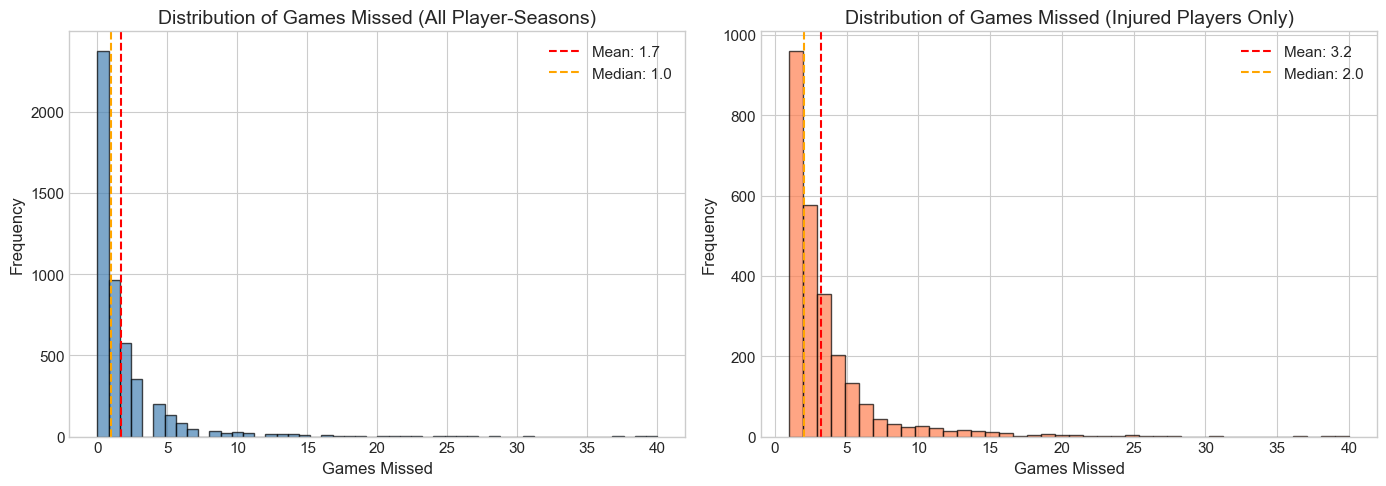

Saved: ../figures/target_distribution.png


In [9]:
# Distribution of games_missed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regular histogram
ax1 = axes[0]
ax1.hist(df_analysis['games_missed'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Games Missed')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Games Missed (All Player-Seasons)')
ax1.axvline(df_analysis['games_missed'].mean(), color='red', linestyle='--', label=f'Mean: {df_analysis["games_missed"].mean():.1f}')
ax1.axvline(df_analysis['games_missed'].median(), color='orange', linestyle='--', label=f'Median: {df_analysis["games_missed"].median():.1f}')
ax1.legend()

# Histogram excluding zeros
ax2 = axes[1]
injured_only = df_analysis[df_analysis['games_missed'] > 0]['games_missed']
ax2.hist(injured_only, bins=40, edgecolor='black', alpha=0.7, color='coral')
ax2.set_xlabel('Games Missed')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Games Missed (Injured Players Only)')
ax2.axvline(injured_only.mean(), color='red', linestyle='--', label=f'Mean: {injured_only.mean():.1f}')
ax2.axvline(injured_only.median(), color='orange', linestyle='--', label=f'Median: {injured_only.median():.1f}')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/target_distribution.png")

In [10]:
# Games missed by season - trend analysis
season_injury_stats = df_analysis.groupby('season').agg({
    'games_missed': ['sum', 'mean', 'median'],
    'player_id': 'count'
}).round(2)
season_injury_stats.columns = ['total_games_missed', 'mean_games_missed', 'median_games_missed', 'player_count']
season_injury_stats = season_injury_stats.reset_index()

print("Games Missed by Season:")
print(season_injury_stats)

Games Missed by Season:
    season  total_games_missed  mean_games_missed  median_games_missed  player_count
0  2010-11                 814               1.80                  1.0           453
1  2011-12                1302               2.72                  1.0           478
2  2012-13                1218               2.60                  1.0           469
3  2013-14                1719               3.57                  1.0           482
4  2014-15                 611               1.24                  1.0           492
5  2015-16                 711               1.49                  1.0           478
6  2016-17                 719               1.48                  1.0           486
7  2017-18                 607               1.12                  1.0           540
8  2018-19                 556               1.05                  1.0           530
9  2019-20                   0               0.00                  0.0           529


**Note:** The 2019-20 season shows 0 games missed due to incomplete injury data (likely COVID-shortened season). This season should be treated with caution in downstream analysis.

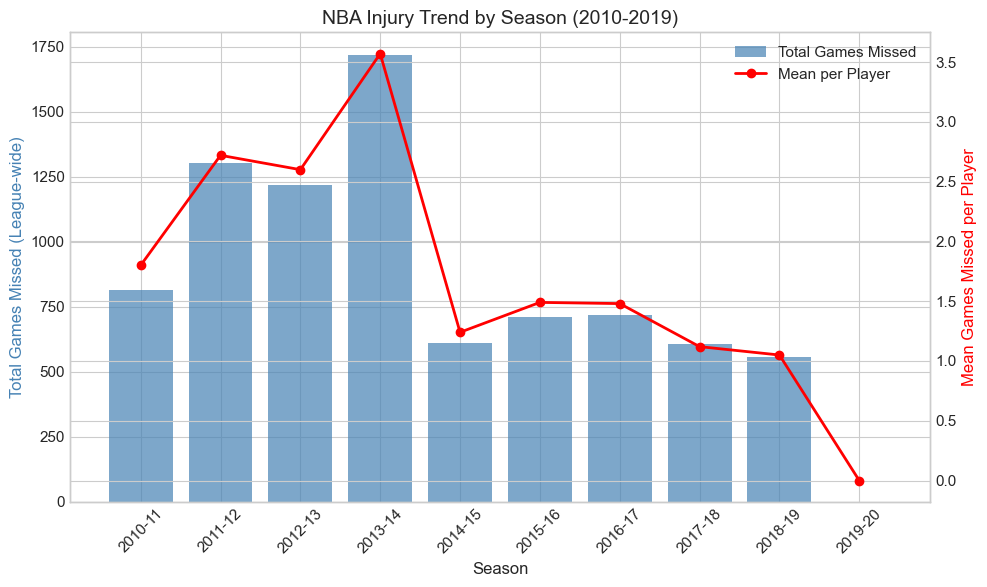

Saved: ../figures/injury_trend_by_season.png


In [11]:
# Trend plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(season_injury_stats['season'], season_injury_stats['total_games_missed'], 
       color='steelblue', alpha=0.7, label='Total Games Missed')

ax2 = ax.twinx()
ax2.plot(season_injury_stats['season'], season_injury_stats['mean_games_missed'], 
         color='red', marker='o', linewidth=2, label='Mean per Player')

ax.set_xlabel('Season')
ax.set_ylabel('Total Games Missed (League-wide)', color='steelblue')
ax2.set_ylabel('Mean Games Missed per Player', color='red')
ax.set_title('NBA Injury Trend by Season (2010-2019)')
ax.tick_params(axis='x', rotation=45)

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'injury_trend_by_season.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/injury_trend_by_season.png")

In [12]:
# Create age groups
df_analysis['age_group'] = pd.cut(
    df_analysis['age'], 
    bins=[0, 25, 30, 100], 
    labels=['Under 25', '25-30', 'Over 30']
)

# Create position groups from team abbreviation (approximation)
# We'll use a simple heuristic based on height
df_analysis['position_group'] = pd.cut(
    df_analysis['player_height_inches'].fillna(df_analysis['player_height_inches'].median()),
    bins=[0, 76, 81, 100],
    labels=['Guard (G)', 'Forward (F)', 'Center (C)']
)

print("Age group distribution:")
print(df_analysis['age_group'].value_counts())
print("\nPosition group distribution:")
print(df_analysis['position_group'].value_counts())

Age group distribution:
age_group
Under 25    2217
25-30       1734
Over 30      986
Name: count, dtype: int64

Position group distribution:
position_group
Forward (F)    2385
Center (C)     1301
Guard (G)      1251
Name: count, dtype: int64


/var/folders/tt/q6yxx0qn7dq_jbphcnvcmtfr0000gn/T/ipykernel_92218/2225423763.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_injury = df_analysis.groupby('age_group')['games_missed'].mean()
/var/folders/tt/q6yxx0qn7dq_jbphcnvcmtfr0000gn/T/ipykernel_92218/2225423763.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pos_injury = df_analysis.groupby('position_group')['games_missed'].mean()


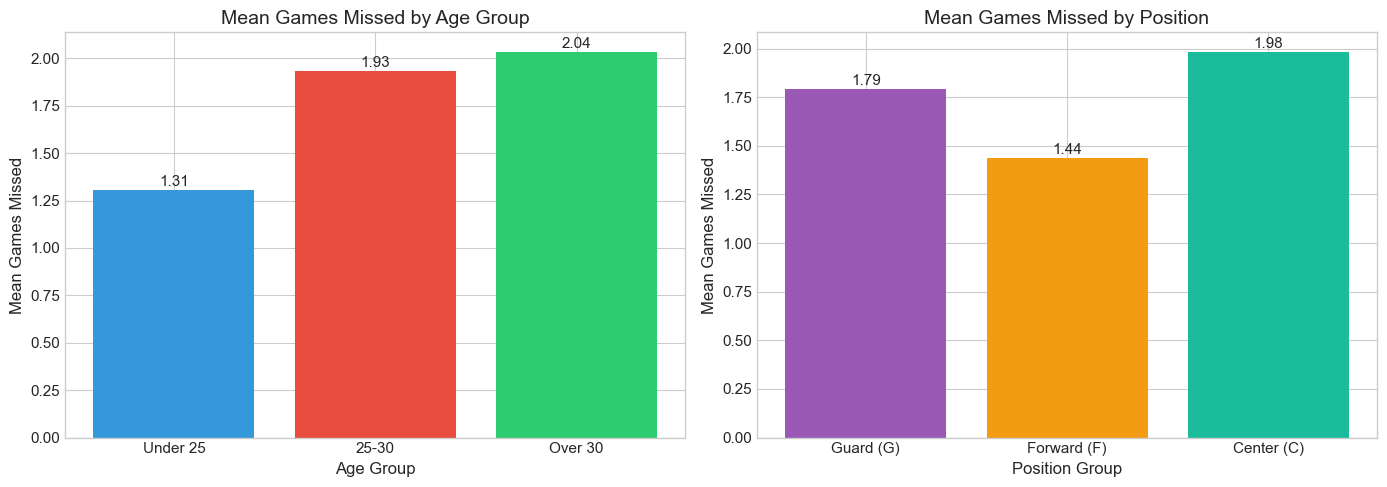

In [13]:
# Games missed by age group and position
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By age group
age_injury = df_analysis.groupby('age_group', observed=False)['games_missed'].mean()
axes[0].bar(age_injury.index.astype(str), age_injury.values, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Mean Games Missed')
axes[0].set_title('Mean Games Missed by Age Group')
for i, v in enumerate(age_injury.values):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=11)

# By position
pos_injury = df_analysis.groupby('position_group', observed=False)['games_missed'].mean()
axes[1].bar(pos_injury.index.astype(str), pos_injury.values, color=['#9b59b6', '#f39c12', '#1abc9c'])
axes[1].set_xlabel('Position Group')
axes[1].set_ylabel('Mean Games Missed')
axes[1].set_title('Mean Games Missed by Position')
for i, v in enumerate(pos_injury.values):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

Crossing age group with position reveals which combinations carry the highest injury burden.

/var/folders/tt/q6yxx0qn7dq_jbphcnvcmtfr0000gn/T/ipykernel_92218/416735076.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df_analysis.pivot_table(


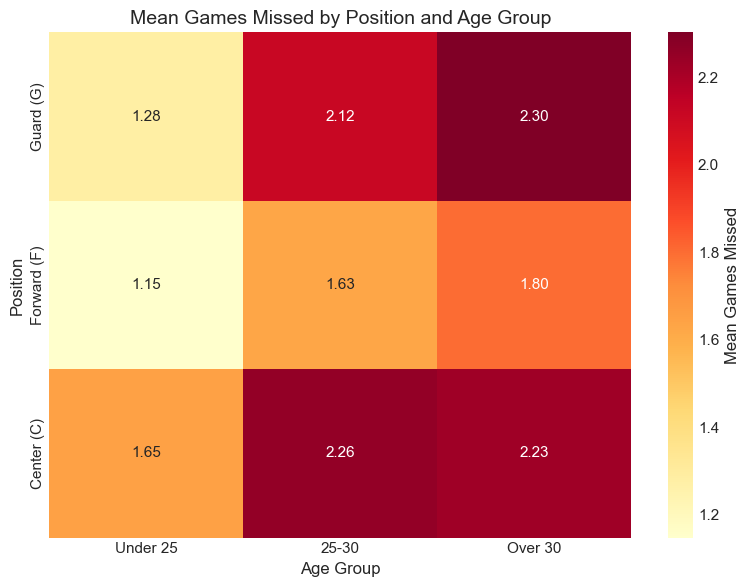

Saved: ../figures/injury_by_age_position.png


In [14]:
# Heatmap: Games missed by position x age group
pivot_table = df_analysis.pivot_table(
    values='games_missed',
    index='position_group',
    columns='age_group',
    aggfunc='mean',
    observed=False
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Mean Games Missed'})
ax.set_title('Mean Games Missed by Position and Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Position')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'injury_by_age_position.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/injury_by_age_position.png")

---
## 3. Feature Distributions

In [15]:
# Key features to analyze
key_features = ['age', 'gp', 'min', 'pts', 'reb', 'ast', 'player_weight']

# Check which features exist
available_features = [f for f in key_features if f in df_analysis.columns]
print(f"Analyzing features: {available_features}")

Analyzing features: ['age', 'gp', 'min', 'pts', 'reb', 'ast', 'player_weight']


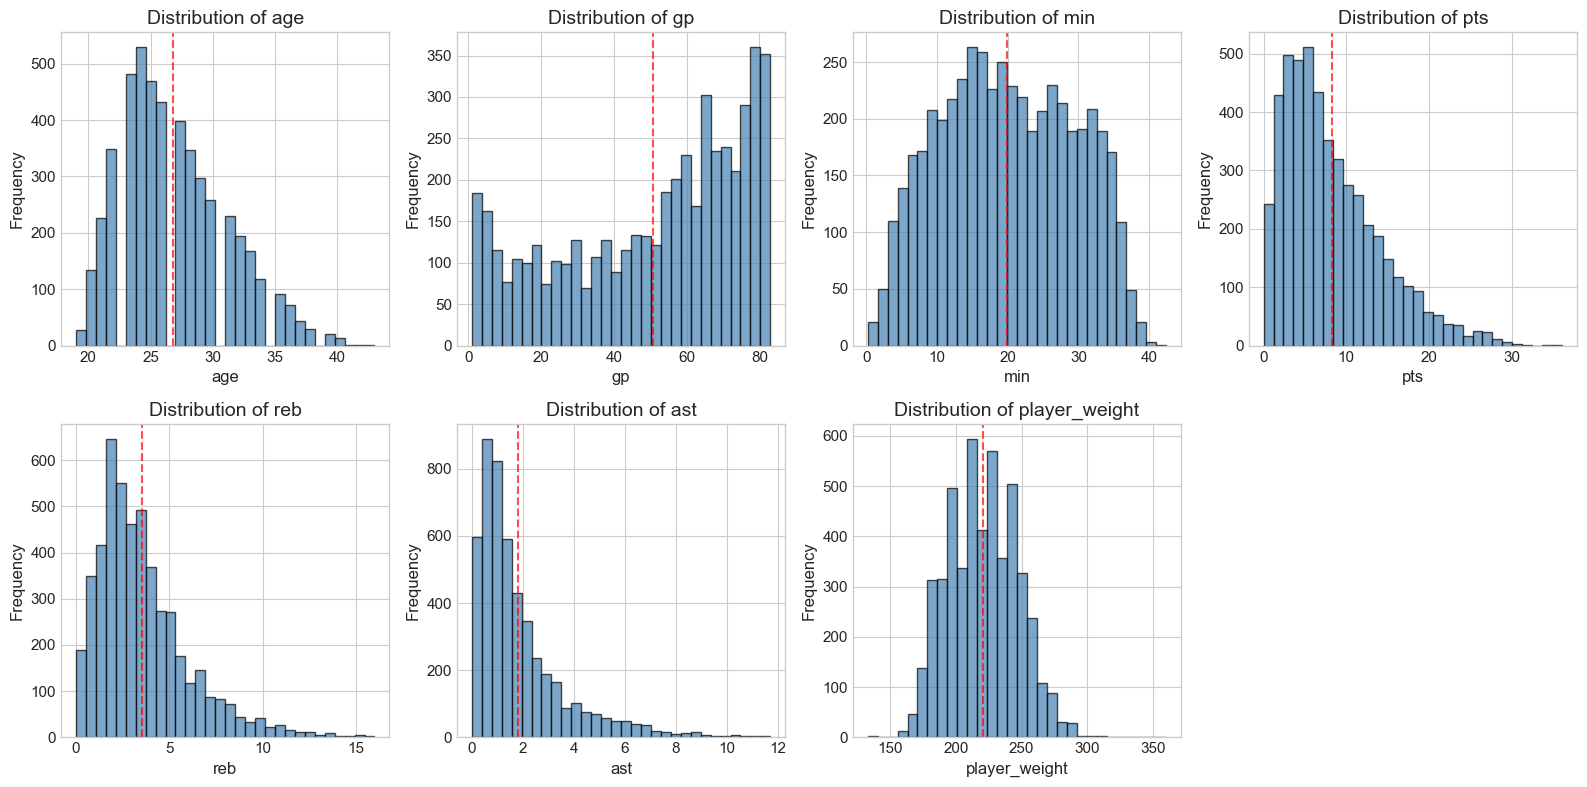

In [16]:
# Distribution plots for key features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(available_features):
    ax = axes[i]
    data = df_analysis[feature].dropna()
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {feature}')
    ax.axvline(data.mean(), color='red', linestyle='--', alpha=0.7)

# Hide unused subplots
for j in range(len(available_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


Tracking data available for 3536 player-seasons (71.6%)


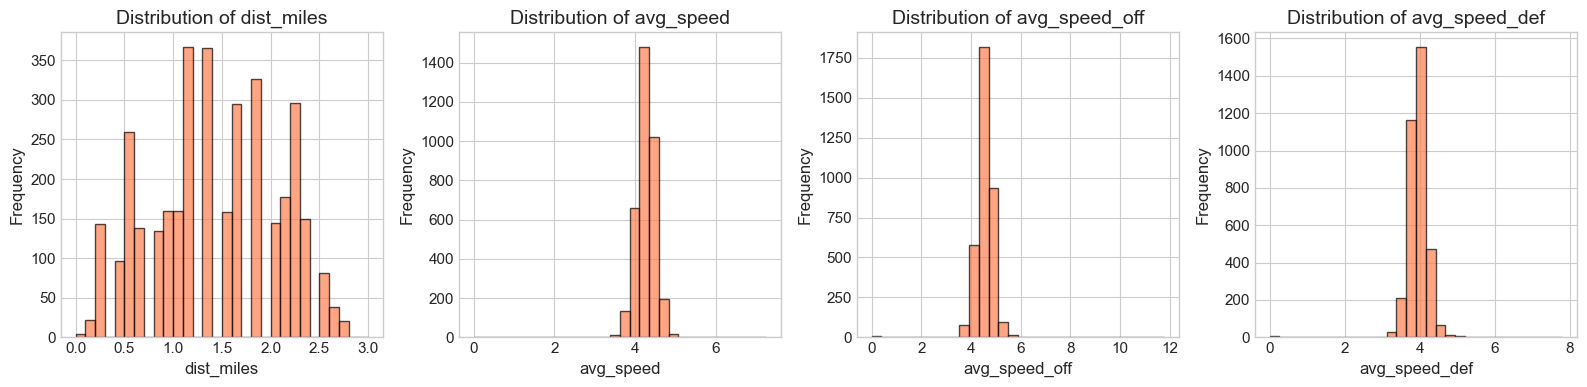

In [17]:
# Tracking data distribution (2013+ only)
tracking_features = ['dist_miles', 'avg_speed', 'avg_speed_off', 'avg_speed_def']
df_tracking_only = df_analysis[df_analysis['dist_miles'].notna()]

print(f"\nTracking data available for {len(df_tracking_only)} player-seasons ({len(df_tracking_only)/len(df_analysis)*100:.1f}%)")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, feature in enumerate(tracking_features):
    ax = axes[i]
    data = df_tracking_only[feature].dropna()
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color='coral')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

In [18]:
# Check for outliers
print("\nPotential Outliers (values beyond 3 std):")
for feature in available_features:
    data = df_analysis[feature].dropna()
    mean, std = data.mean(), data.std()
    outliers = data[(data < mean - 3*std) | (data > mean + 3*std)]
    if len(outliers) > 0:
        print(f"  {feature}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.2f}%)")


Potential Outliers (values beyond 3 std):
  age: 18 outliers (0.36%)
  pts: 59 outliers (1.20%)
  reb: 80 outliers (1.62%)
  ast: 101 outliers (2.05%)
  player_weight: 9 outliers (0.18%)


Outliers are minimal (<2% for most features). No extreme cleaning needed.

---
## 4. Injury History Deep Dive

In [25]:
# Players with most total games missed
player_total_injuries = df_analysis.groupby(['player_id', 'player_name']).agg({
    'games_missed': 'sum',
    'injury_events': 'sum',
    'season': 'count'
}).reset_index()
player_total_injuries.columns = ['player_id', 'player_name', 'total_games_missed', 'total_injury_events', 'seasons_played']
player_total_injuries['games_missed_per_season'] = player_total_injuries['total_games_missed'] / player_total_injuries['seasons_played']

top_20_injured = player_total_injuries.nlargest(20, 'total_games_missed')
print("Top 20 Most Injury-Prone Players (2010-2019):")
print(top_20_injured[['player_name', 'total_games_missed', 'total_injury_events', 'seasons_played', 'games_missed_per_season']].to_string(index=False))

Top 20 Most Injury-Prone Players (2010-2019):
     player_name  total_games_missed  total_injury_events  seasons_played  games_missed_per_season
      Kevin Love                  77                   36              10                 7.700000
     Jason Smith                  68                   13               9                 7.555556
     Eric Gordon                  63                   30              10                 6.300000
   Jordan Farmar                  61                    8               6                10.166667
   Jameer Nelson                  57                   33               8                 7.125000
   Anthony Davis                  56                   35               8                 7.000000
    Trevor Ariza                  54                   20              10                 5.400000
        CJ Miles                  52                   26              10                 5.200000
            Nene                  50                   33      

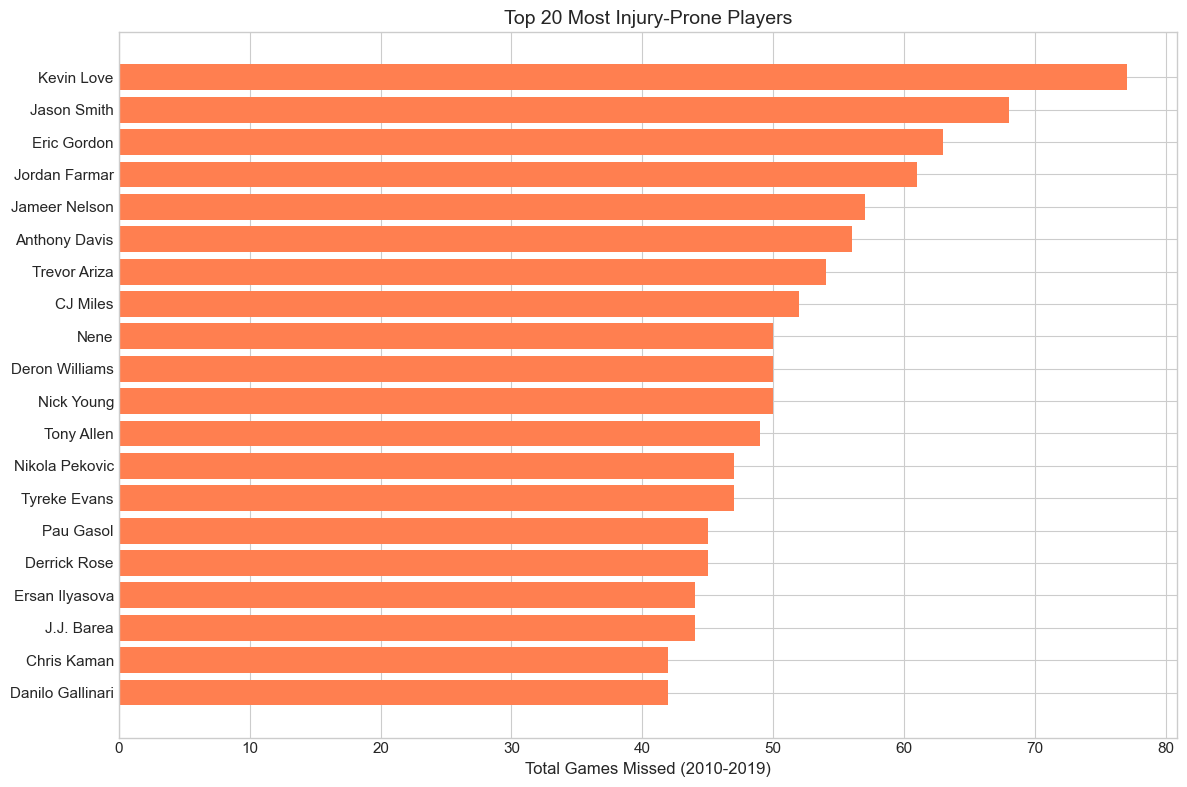

In [26]:
# Plot top 20
fig, ax = plt.subplots(figsize=(12, 8))

top_20_injured_sorted = top_20_injured.sort_values('total_games_missed', ascending=True)
ax.barh(top_20_injured_sorted['player_name'], top_20_injured_sorted['total_games_missed'], color='coral')
ax.set_xlabel('Total Games Missed (2010-2019)')
ax.set_title('Top 20 Most Injury-Prone Players')

plt.tight_layout()
plt.show()

Do players who get injured tend to get injured again? This repeat-injury pattern is critical for prediction.

In [27]:
# Repeat injury analysis: consecutive season injuries
df_analysis['injured_this_season'] = (df_analysis['games_missed'] > 0).astype(int)
df_analysis['injured_last_season'] = df_analysis.groupby('player_id')['injured_this_season'].shift(1)

# Calculate repeat injury rate
df_with_prior = df_analysis.dropna(subset=['injured_last_season'])
repeat_injury_rate = df_with_prior.groupby('injured_last_season')['injured_this_season'].mean()

print("Repeat Injury Analysis:")
print(f"  If NOT injured last season: {repeat_injury_rate[0]*100:.1f}% chance of injury this season")
print(f"  If injured last season: {repeat_injury_rate[1]*100:.1f}% chance of injury this season")
print(f"  Relative risk increase: {repeat_injury_rate[1]/repeat_injury_rate[0]:.2f}x")

Repeat Injury Analysis:
  If NOT injured last season: 43.0% chance of injury this season
  If injured last season: 64.3% chance of injury this season
  Relative risk increase: 1.50x


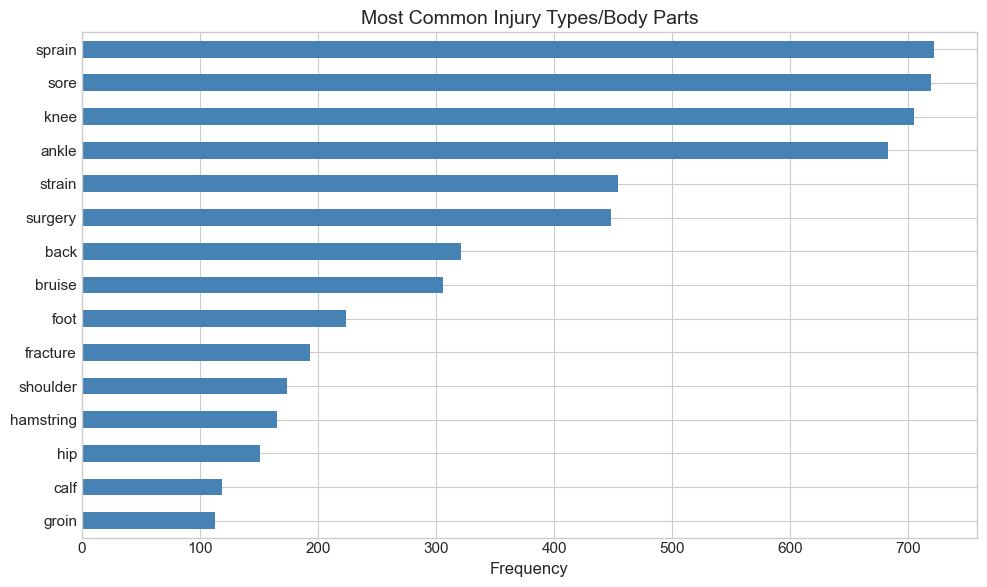

In [28]:
# Injury types analysis (from original injury data)
if 'injury_types' in df_injuries.columns:
    # Flatten injury types
    all_injury_types = []
    for types in df_injuries['injury_types'].dropna():
        if isinstance(types, str):
            # Parse string representation of list
            types = eval(types)
        all_injury_types.extend(types)
    
    # Count frequencies
    injury_type_counts = pd.Series(all_injury_types).value_counts().head(15)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    injury_type_counts.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Frequency')
    ax.set_title('Most Common Injury Types/Body Parts')
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

Knee and ankle injuries dominate, consistent with the physical demands of basketball.

---
## 5. Data Quality Summary

In [ ]:
# Missing data analysis
missing_pct = (df_analysis.isnull().sum() / len(df_analysis) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print("Missing Data by Column (>0%):")
for col, pct in missing_pct.items():
    print(f"  {col}: {pct:.1f}%")

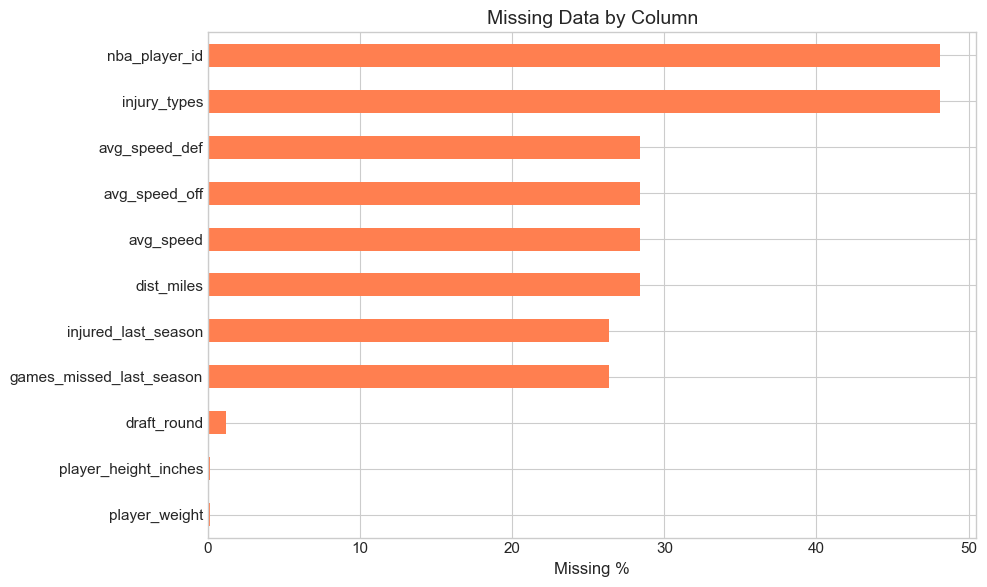

In [32]:
# Visualize missing data
if len(missing_pct) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    missing_pct.head(15).plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Data by Column')
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

In [33]:
# Tracking data coverage by season
tracking_coverage = df_analysis.groupby('season')['dist_miles'].apply(lambda x: x.notna().mean() * 100)
print("\nTracking Data Coverage by Season:")
for season, coverage in tracking_coverage.items():
    status = '(Available)' if coverage > 50 else '(Not Available)'
    print(f"  {season}: {coverage:.0f}% {status}")


Tracking Data Coverage by Season:
  2010-11: 0% (Not Available)
  2011-12: 0% (Not Available)
  2012-13: 0% (Not Available)
  2013-14: 100% (Available)
  2014-15: 100% (Available)
  2015-16: 100% (Available)
  2016-17: 100% (Available)
  2017-18: 100% (Available)
  2018-19: 100% (Available)
  2019-20: 100% (Available)


Tracking data is completely unavailable before 2013-14 — this limits its usefulness as a feature across the full dataset.

In [34]:
# Injury data merge coverage
injury_coverage = (df_analysis['games_missed'] > 0).sum()
original_injuries = len(df_injuries)

print(f"\nInjury Data Merge Coverage:")
print(f"  Original injury records: {original_injuries}")
print(f"  Matched to player stats: {injury_coverage}")
print(f"  Coverage: {injury_coverage/original_injuries*100:.1f}%")


Injury Data Merge Coverage:
  Original injury records: 2623
  Matched to player stats: 2562
  Coverage: 97.7%


---
## 6. Summary & Next Steps

In [ ]:
# Generate summary statistics for report
print("="*70)
print("EDA SUMMARY")
print("="*70)

print("\n1. TARGET VARIABLE (games_missed):")
print(f"   - Mean: {df_analysis['games_missed'].mean():.2f} games")
print(f"   - Median: {df_analysis['games_missed'].median():.0f} games")
print(f"   - Std: {df_analysis['games_missed'].std():.2f}")
print(f"   - Skewness: {df_analysis['games_missed'].skew():.2f} (highly right-skewed)")
print(f"   - Zero-inflation: {(df_analysis['games_missed']==0).mean()*100:.1f}% have 0 games missed")

print("\n2. INJURY PATTERNS:")
print(f"   - {(df_analysis['games_missed'] > 0).mean()*100:.1f}% of player-seasons had at least one injury")
print(f"   - If NOT injured last season: {repeat_injury_rate[0]*100:.1f}% chance of injury this season")
print(f"   - If injured last season: {repeat_injury_rate[1]*100:.1f}% chance of injury this season")
print(f"   - Relative risk: {repeat_injury_rate[1]/repeat_injury_rate[0]:.2f}x")

print("\n3. AGE EFFECT:")
age_effect = df_analysis.groupby('age_group', observed=False)['games_missed'].mean()
for age_grp, mean_missed in age_effect.items():
    print(f"   - {age_grp}: {mean_missed:.2f} mean games missed")

print("\n4. DATA COVERAGE:")
print(f"   - Tracking data: {len(df_tracking_only)/len(df_analysis)*100:.1f}% of player-seasons (2013+ only)")
print(f"   - Injury merge coverage: {(df_analysis['games_missed'] > 0).sum()}/{len(df_injuries)} ({(df_analysis['games_missed'] > 0).sum()/len(df_injuries)*100:.1f}%)")

### Key Findings

1. **Target variable** is highly right-skewed (skewness: 4.48) with 48% zero-inflation
2. **Repeat injury risk** — players injured last season have 1.5x higher injury rate the following season
3. **Age effect** — older players (30+) miss about 2x more games than players under 25
4. **2013-14 was the peak injury season** with 1,719 total games missed league-wide
5. **Tracking data** only available 2013+, limiting full-dataset coverage
6. **2019-20 data is incomplete** — should be excluded or handled carefully

### Data Exported

- `data/processed/analysis_merged.csv` — merged dataset for feature engineering

### Next Steps

Proceed to `04_feature_engineering.ipynb`.

In [37]:
# Save the analysis dataframe for feature engineering
output_path = f'../{PROCESSED_DIR}/analysis_merged.csv'
df_analysis.to_csv(output_path, index=False)
print(f"\nSaved merged analysis data: {output_path}")
print(f"Shape: {df_analysis.shape}")


Saved merged analysis data: ../data/processed/analysis_merged.csv
Shape: (4937, 88)
